In [ ]:
import torch 
import numpy as np 
import torch.nn.functional as F
from tqdm import tqdm

import matplotlib as mpl 
import matplotlib.pyplot as plt 

import os 
import json

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica", 
})

with open('/Users/henrywilliams/Documents/programming/python/ai/malbert-test/notebooks/obfuscation-experiment-files.json', 'r') as file: 
    dataset = json.load(file)


In [10]:
results = {
    "base": {
        'all': '/Users/henrywilliams/Documents/programming/python/ai/cnn-malware-detector/obfuscation-experiment-results/base-all', 
        'benign': '/Users/henrywilliams/Documents/programming/python/ai/cnn-malware-detector/obfuscation-experiment-results/base-benign', 
        'malicious': '/Users/henrywilliams/Documents/programming/python/ai/cnn-malware-detector/obfuscation-experiment-results/base-malicious', 
    },
    "filtered": {
        'all': '/Users/henrywilliams/Documents/programming/python/ai/cnn-malware-detector/obfuscation-experiment-results/filtered-all', 
        'benign': '/Users/henrywilliams/Documents/programming/python/ai/cnn-malware-detector/obfuscation-experiment-results/filtered-benign', 
        'malicious': '/Users/henrywilliams/Documents/programming/python/ai/cnn-malware-detector/obfuscation-experiment-results/filtered-malicious', 
    },
}

In [11]:
def get_results(results_path):
    return [os.path.join(results_path, file) for file in os.listdir(results_path) if not file.startswith('.')]

In [12]:
def get_accuracy(results_path):
    with open(os.path.join(results_path, 'results.json'), 'r') as results:
        results = json.load(results)

    return [result['accuracy'] for result in results]

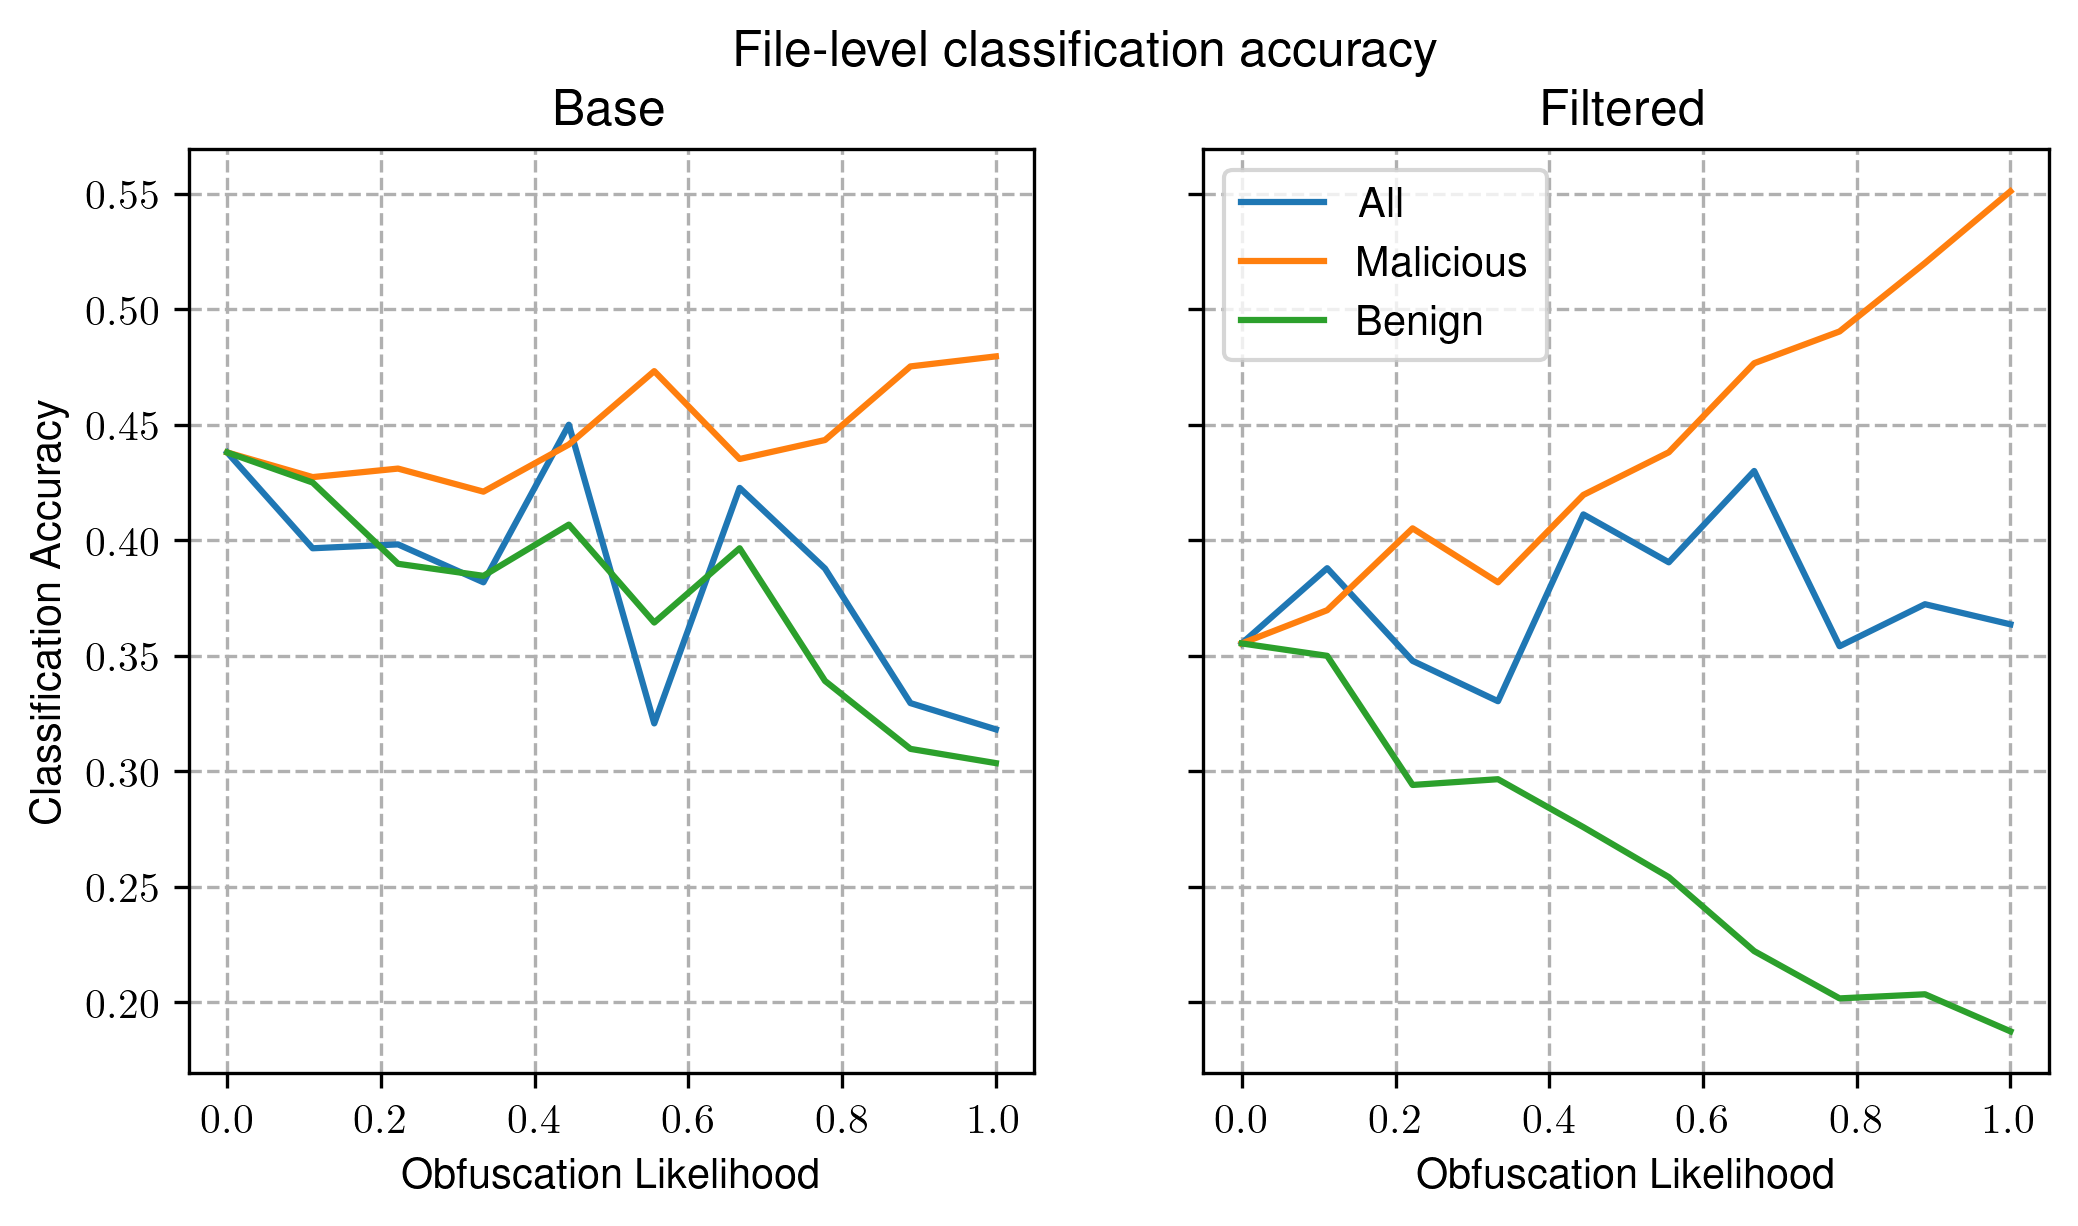

In [13]:
fig, axs = plt.subplots(1,2, dpi=300, sharey=True, sharex=True, figsize=(8,4))
fig.suptitle("File-level classification accuracy")
ps = np.linspace(0., 1., 10)
axs[0].set_ylabel("Classification Accuracy")
for i, m in enumerate(['base', 'filtered']):
    axs[i].title.set_text(m.title())
    axs[i].grid(linestyle='--')
    axs[i].set_xlabel("Obfuscation Likelihood")
    for l in ['all', 'malicious', 'benign']:
        axs[i].plot(ps, get_accuracy(results[m][l]), label=l.title())
axs[1].legend()
plt.show()

In [ ]:
def get_step(results_path, step):
    return os.path.join(results_path, f'step-{step}')

def get_logit_paths(results_path, step=0):
    path = get_step(results_path, step)
    logits_path = os.path.join(path, 'logits')
    logit_files = [os.path.join(logits_path, file) for file in os.listdir(logits_path) if file.endswith('.pt')]
    return sorted(logit_files, key=lambda file: os.path.getctime(file))

In [18]:
def get_avg_certainty_at_step(results_path, step=0):
    logit_files = get_logit_paths(results_path, step)
    certainty = []

    for file in logit_files:
        logits = torch.load(file)              
        probs = F.softmax(logits, dim=1)       
        uniform = torch.full_like(probs, 0.5)  

        kl_div = F.kl_div(uniform.log(), probs, reduction='none').sum(dim=1)  # KL(p || u)
        certainty.append(kl_div.mean().item())

    return np.mean(certainty), np.std(certainty)

def get_avg_certainty(results_path):
    with open(os.path.join(results_path, "config.json"), "r") as f: 
        config = json.load(f)
    
    return [get_avg_certainty_at_step(results_path, i) for i in range(config['steps'])]

Generating plot...: 100%|██████████| 6/6 [00:05<00:00,  1.26it/s]

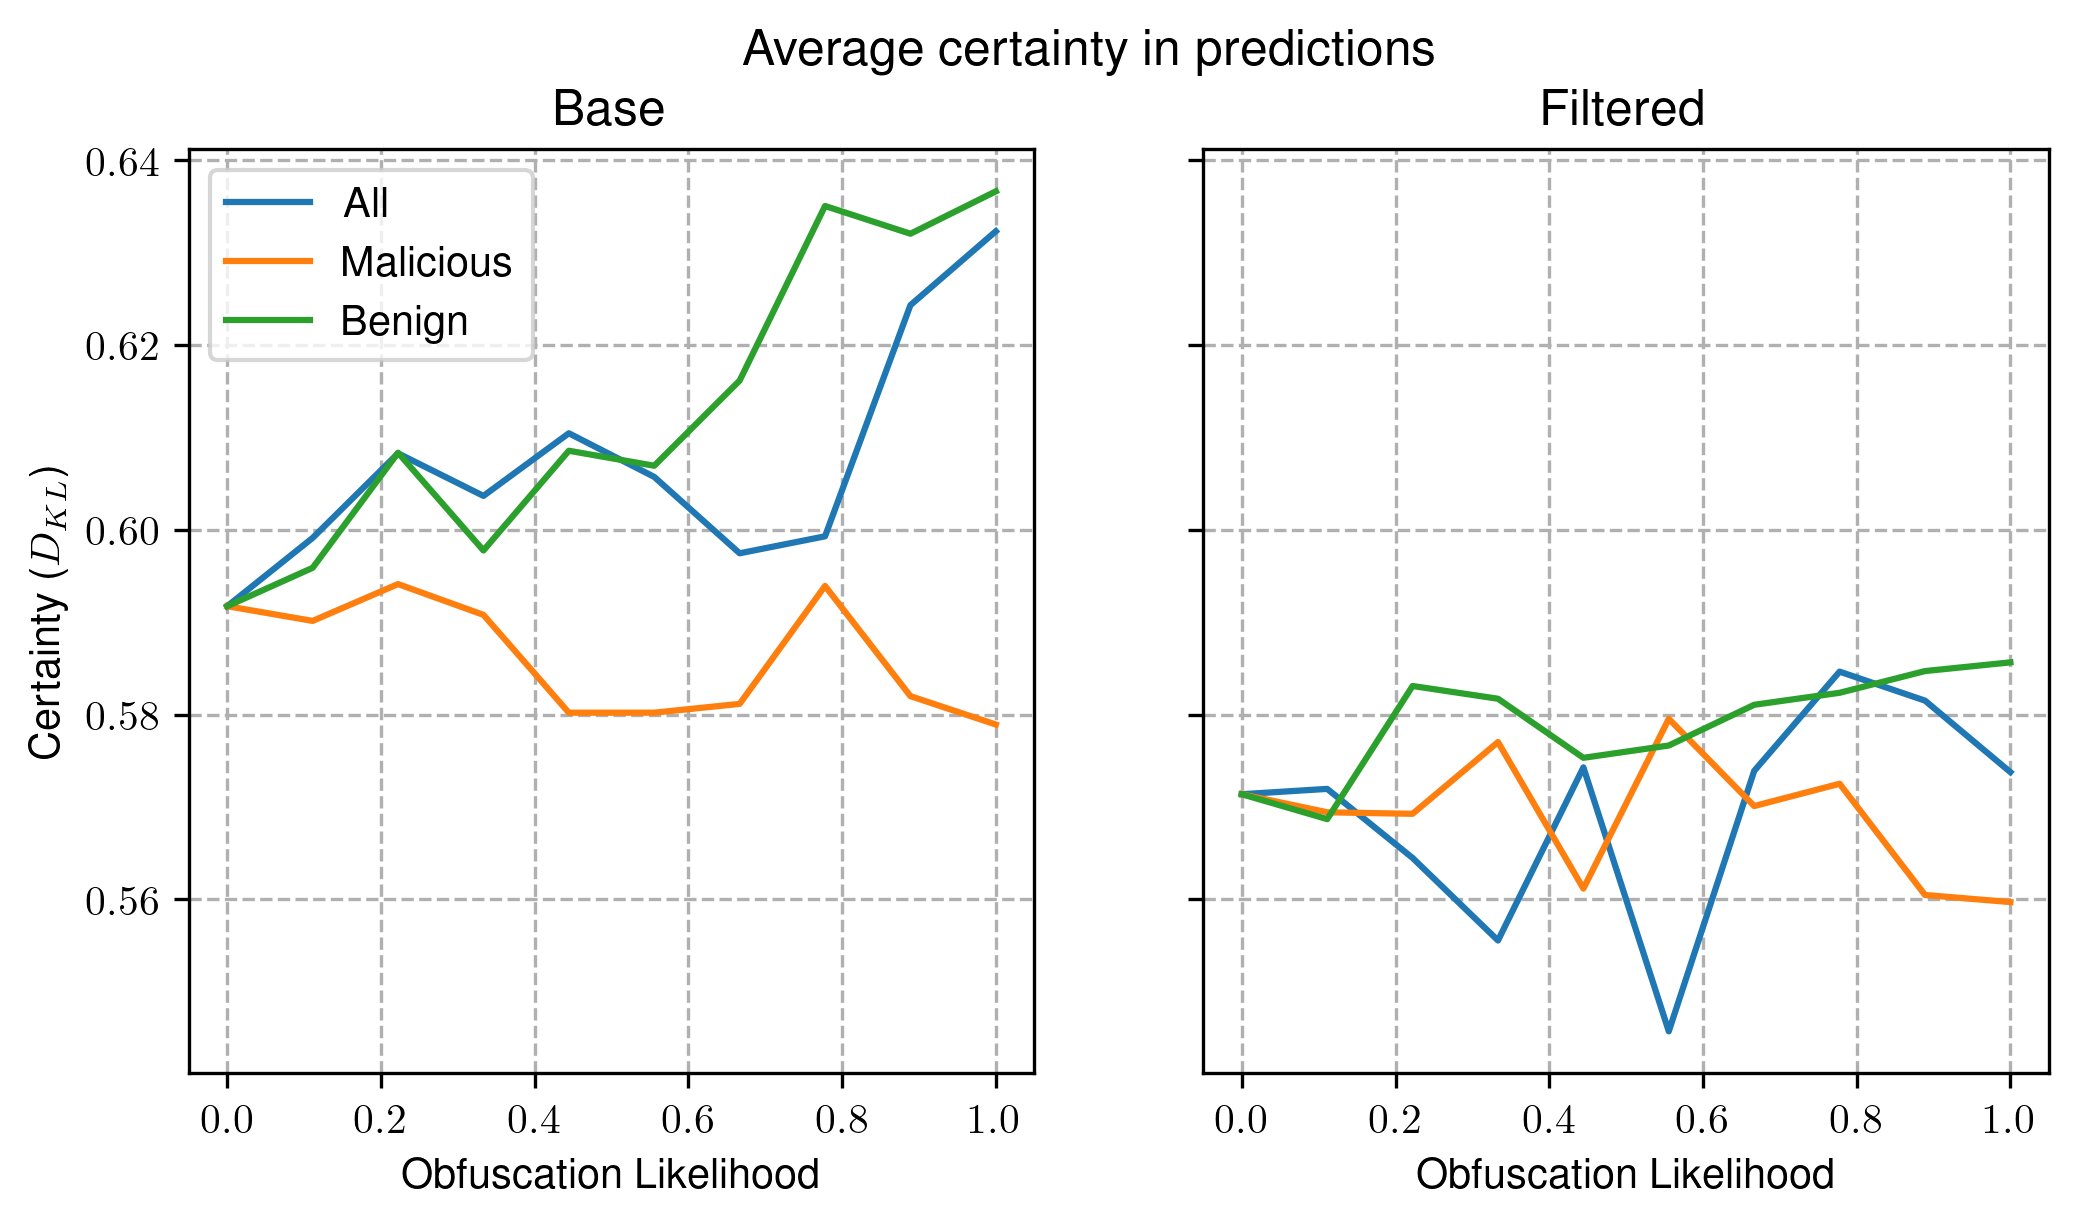

In [20]:
fig, axs = plt.subplots(1,2, dpi=300, sharey=True, sharex=True, figsize=(8,4))
fig.suptitle("Average certainty in predictions")
ps = np.linspace(0., 1., 10)
axs[0].set_ylabel(r"Certainty ($D_{KL}$)")
loop = tqdm(desc='Generating plot...', total=6, leave=False)

for i, m in enumerate(['base', 'filtered']):
    axs[i].title.set_text(m.title())
    axs[i].grid(linestyle='--')
    axs[i].set_xlabel("Obfuscation Likelihood")

    for l in ['all', 'malicious', 'benign']:
    
        certainty = np.array(get_avg_certainty(results[m][l]))
        mean = certainty[:, 0]
        std = certainty[:, 1]
        axs[i].plot(ps, mean, label=l.title())
        # axs[i].fill_between(ps, mean - std, mean + std, alpha=0.5)
        loop.update(1)
axs[0].legend()
plt.show()